# *#Clustering Plant Iris Using Principal component Analysis*

## Importing the basic libraries

In [14]:
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Importing the dataset

In [15]:
dataset = datasets.load_iris()

### Dataset Segregation

In [16]:
X = dataset.data
y = dataset.target
names = dataset.target_names

# *StandardScaler*

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Fitting the PCA clustering to the dataset with n=2

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = PCA(n_components=2)
X_pca = model.fit_transform(X_scaled)

In [19]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# *map cluster*

In [20]:
# Map clusters to actual species
from collections import Counter

mapping = {}

for i in range(3):
    labels = y[clusters == i]
    if len(labels) > 0:
        mapping[i] = Counter(labels).most_common(1)[0][0]

# Convert numeric → species name
species_map = {i: names[val] for i, val in mapping.items()}

# *Explained Variance*

In [21]:
print("Explained Variance Ratio:", model.explained_variance_ratio_)

Explained Variance Ratio: [0.72962445 0.22850762]


# *USER INPUT*

Explained Variance Ratio: [0.72962445 0.22850762]

Enter Iris Flower Details
Sepal Length: 24
Sepal Width: 26
Petal Length: 68
Petal Width: 54

PCA Coordinates: [[57.69030459 62.61239548]]


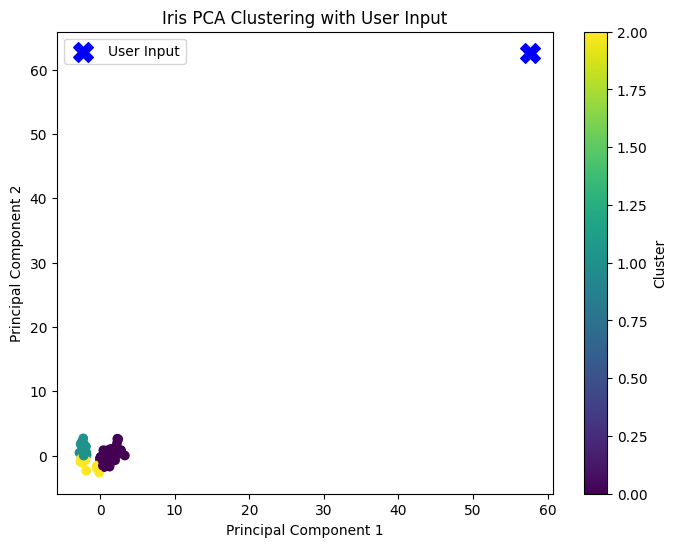

In [22]:
# Import Libraries
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset
dataset = datasets.load_iris()

X = dataset.data
y = dataset.target
names = dataset.target_names

# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# ==============================
# USER INPUT
# ==============================

print("\nEnter Iris Flower Details")

sepal_length = float(input("Sepal Length: "))
sepal_width = float(input("Sepal Width: "))
petal_length = float(input("Petal Length: "))
petal_width = float(input("Petal Width: "))

user_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

# Standardize user input
user_scaled = scaler.transform(user_data)

# Transform using PCA
user_pca = pca.transform(user_scaled)

print("\nPCA Coordinates:", user_pca)

# ==============================
# VISUALIZATION
# ==============================

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA + KMeans Clustering")
plt.colorbar(label="Cluster")

# Plot user point
plt.scatter(
    user_pca[0,0],
    user_pca[0,1],
    color='blue',
    marker='X',
    s=200,
    label='User Input'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris PCA Clustering with User Input")
plt.legend()

plt.show()

*Variance Percentage and visualization*

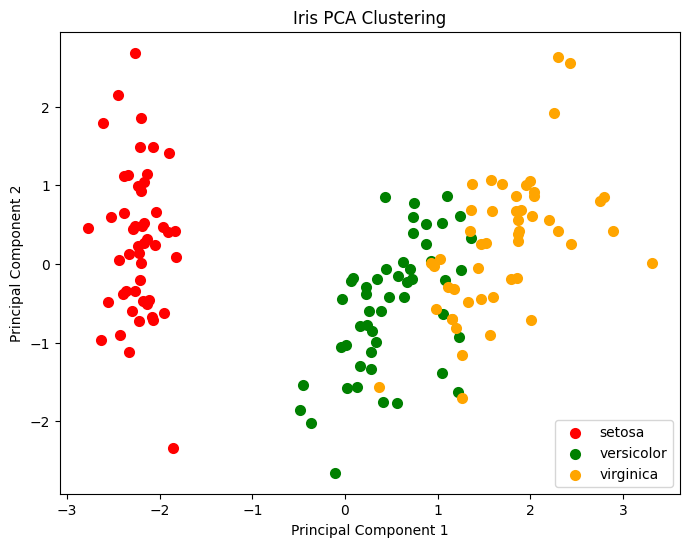

In [23]:
plt.figure(figsize=(8,6))

colors = ['red','green','orange']

for color, i, target_name in zip(colors, [0,1,2], names):
    plt.scatter(
        X_pca[y == i,0],
        X_pca[y == i,1],
        color=color,
        lw=2,
        label=target_name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris PCA Clustering")
plt.legend()
plt.show()

# *variance bar chart*

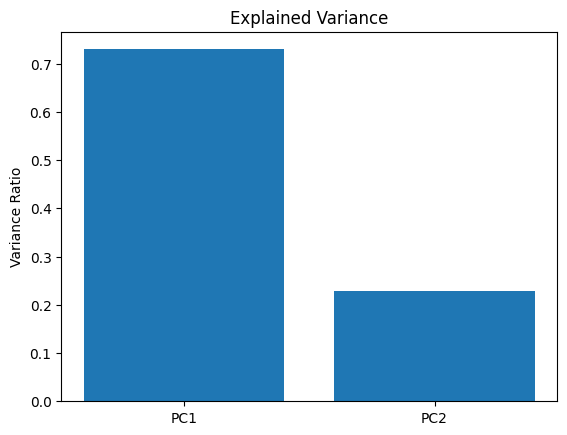

In [24]:
plt.bar(
    ['PC1','PC2'],
    model.explained_variance_ratio_
)

plt.title("Explained Variance")
plt.ylabel("Variance Ratio")
plt.show()